# distopt: default experiments (with MUDAG)

This notebook runs **baseline convergence-speed sanity checks** for the `distopt` harness on small quadratic instances.

What it does:
- Sweeps basic hyperparameters for DGD / EXTRA / Gradient Tracking / MUDAG on a fixed baseline scenario.
- Benchmarks algorithms with **two x-axes**:
  - communication: `mix_rounds`
  - computation: `grad_evals_per_node`
- Repeats everything over **3 seeds** and plots the **median** curve (thin lines show per-seed runs where helpful).

Notes:
- `t` is not comparable across algorithms (GT does 2 mixes/iter; MUDAG does `K+1` mixes/outer-iter). Compare by `mix_rounds` and/or `grad_evals_per_node`.
- MUDAG requires a PSD mixing matrix `W`. We enforce this by building graphs with `lazy=0.5` (lazification: `W ← (W+I)/2`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path so `import research...` works no matter
# which working directory VS Code/Jupyter chooses for this notebook.
_here = Path().resolve()
_repo_root = None
for p in [_here, *_here.parents]:
    if (p / "pyproject.toml").exists():
        _repo_root = p
        break
if _repo_root is not None and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from research.code.distopt.generators import (
    path_adjacency,
    cycle_adjacency,
    complete_adjacency,
    erdos_renyi_adjacency,
    make_graph_from_adjacency,
    make_wishart_ridge_problem,
    make_shared_eigenbasis_problem,
    make_random_spd_problem,
)
from research.code.distopt.algorithms import DGD, EXTRA, GradientTracking, MUDAG
from research.code.distopt.runner import run_experiment, MaxMixRounds

In [2]:
def _consensus_init(X: np.ndarray) -> np.ndarray:
    """Return consensus initialization with the same average as X."""
    x0_bar = np.mean(X, axis=0)
    return np.repeat(x0_bar[None, :], X.shape[0], axis=0)


def make_connected_er_graph(n: int, p: float, *, seed: int, lazy: float, max_tries: int = 50):
    for k in range(max_tries):
        adj = erdos_renyi_adjacency(n, p, seed=seed + k)
        graph = make_graph_from_adjacency(adj, lazy=lazy)
        if graph.ensure_stats().connected:
            return graph
    raise RuntimeError(f"Failed to sample a connected ER graph after {max_tries} tries")


def build_graph(kind: str, n: int, *, seed: int, lazy: float, er_p: float = 0.3):
    if kind == "path":
        adj = path_adjacency(n)
    elif kind == "cycle":
        adj = cycle_adjacency(n)
    elif kind == "complete":
        adj = complete_adjacency(n)
    elif kind == "er":
        return make_connected_er_graph(n, er_p, seed=seed, lazy=lazy)
    else:
        raise ValueError(f"Unknown graph kind={kind!r}")

    graph = make_graph_from_adjacency(adj, lazy=lazy)
    if not graph.ensure_stats().connected:
        raise ValueError(f"Graph kind={kind!r} is not connected at n={n}")
    return graph


def build_problem(family: str, graph, *, seed: int, d: int, **kwargs):
    if family == "wishart_ridge":
        return make_wishart_ridge_problem(
            graph,
            d=d,
            m_per_node=int(kwargs.get("m_per_node", 50)),
            lambda_reg=float(kwargs.get("lambda_reg", 1.0)),
            noise_std=float(kwargs.get("noise_std", 0.0)),
            seed=seed,
        )
    if family == "shared_eigenbasis":
        return make_shared_eigenbasis_problem(
            graph,
            d=d,
            mu=float(kwargs.get("mu", 1.0)),
            L=float(kwargs.get("L", 10.0)),
            spectrum=str(kwargs.get("spectrum", "logspace")),
            seed=seed,
        )
    if family == "random_spd":
        return make_random_spd_problem(
            graph,
            d=d,
            mu=float(kwargs.get("mu", 1.0)),
            L=float(kwargs.get("L", 10.0)),
            spectrum=str(kwargs.get("spectrum", "logspace")),
            seed=seed,
        )
    raise ValueError(f"Unknown problem family={family!r}")


def alpha_from_factor(problem, factor: float) -> float:
    L_l = float(problem.ensure_stats().L_l)
    return float(factor) / L_l


def extract_xy(res, *, x_key: str, y_key: str, max_x: float | None = None):
    xs = np.array([row[x_key] for row in res.history], dtype=float)
    ys = np.array([row[y_key] for row in res.history], dtype=float)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    keep = np.concatenate([[True], xs[1:] > xs[:-1]])
    xs, ys = xs[keep], ys[keep]
    if max_x is not None:
        mask = xs <= float(max_x)
        if np.any(mask):
            xs, ys = xs[mask], ys[mask]
    return xs, ys


def interp_to_grid(xs: np.ndarray, ys: np.ndarray, grid: np.ndarray, *, y_floor: float = 1e-16) -> np.ndarray:
    ys = np.maximum(ys, y_floor)
    if xs.size == 0:
        return np.full_like(grid, fill_value=np.nan, dtype=float)
    if xs[0] > grid[0]:
        xs = np.concatenate([[grid[0]], xs])
        ys = np.concatenate([[ys[0]], ys])
    if xs[-1] < grid[-1]:
        xs = np.concatenate([xs, [grid[-1]]])
        ys = np.concatenate([ys, [ys[-1]]])
    return np.interp(grid, xs, ys)


def aggregate_seed_curves(res_by_seed: dict[int, object], *, x_key: str, y_key: str, grid: np.ndarray, max_x: float | None = None):
    per_seed = {}
    ys_stack = []
    for seed, res in res_by_seed.items():
        xs, ys = extract_xy(res, x_key=x_key, y_key=y_key, max_x=max_x)
        y_grid = interp_to_grid(xs, ys, grid)
        per_seed[int(seed)] = y_grid
        ys_stack.append(y_grid)
    ys_stack = np.stack(ys_stack, axis=0)
    return np.median(ys_stack, axis=0), per_seed


def first_budget_to_tol(res, *, x_key: str, y_key: str, tol: float) -> float | None:
    for row in res.history:
        if float(row[y_key]) <= float(tol):
            return float(row[x_key])
    return None


def _fmt_budget(x: float | None) -> str:
    if x is None:
        return "-"
    if not np.isfinite(x):
        return "∞"
    if x >= 1000:
        return f"{x:.0f}"
    return f"{x:.1f}"


def print_graph_stats(graph) -> None:
    g = graph.ensure_stats()
    print(f"connected={g.connected}  gamma={g.gamma:.4g}  chi={g.chi:.3g}  lambda2_W={g.lambda2_W:.6f}")
    print(f"min_eig(W)={float(np.min(g.eigvals_W)):.6g}  max_eig(W)={float(np.max(g.eigvals_W)):.6g}")


def print_problem_stats(problem) -> None:
    s = problem.ensure_stats()
    print(f"kappa_g={s.kappa_g:.3g}  L_g={s.L_g:.3g}  mu_g={s.mu_g:.3g}  L_l={s.L_l:.3g}  beta={s.beta:.3g}")

In [3]:
# Global defaults (fast + deterministic)
seeds = [0, 1, 2]
n = 12
d = 10

# Lazification makes W PSD, which MUDAG requires.
lazy = 0.5

# Budget is in communication rounds; comparisons should use mix_rounds / grads.
max_mix = 3000
log_every = 10

# Accuracy target used for summarizing time-to-accuracy (not for stopping).
tol_dist = 1e-3

alpha_factors = [0.02, 0.05, 0.1, 0.2]
c_K_grid = [0.5, 1.0, 2.0, 3.0]

baseline_graph_kind = "cycle"
baseline_problem_family = "wishart_ridge"
baseline_problem_kwargs = dict(m_per_node=50, lambda_reg=1.0, noise_std=0.0)

mix_grid = np.linspace(0.0, float(max_mix), 201)

print('seeds:', seeds)
print('n,d:', (n, d), 'lazy:', lazy, 'max_mix:', max_mix, 'log_every:', log_every)
print('baseline:', baseline_graph_kind, '+', baseline_problem_family, baseline_problem_kwargs)

seeds: [0, 1, 2]
n,d: (12, 10) lazy: 0.5 max_mix: 3000 log_every: 10
baseline: cycle + wishart_ridge {'m_per_node': 50, 'lambda_reg': 1.0, 'noise_std': 0.0}


In [4]:
# 1) Baseline scenario hyperparameter sweep (3 seeds)

ALG_SPECS = {
    'DGD': lambda alpha: DGD(alpha=alpha),
    'EXTRA': lambda alpha: EXTRA(alpha=alpha),
    'GT': lambda alpha: GradientTracking(alpha=alpha),
}

baseline_runs: dict[str, dict[object, dict[int, object]]] = {}
baseline_stats = {}  # seed -> (graph, problem)

for seed in seeds:
    graph = build_graph(baseline_graph_kind, n, seed=seed, lazy=lazy)
    problem = build_problem(baseline_problem_family, graph, seed=seed, d=d, **baseline_problem_kwargs)
    baseline_stats[int(seed)] = (graph, problem)

    rng = np.random.default_rng(seed)
    X0_raw = rng.normal(size=(n, d))
    X0 = _consensus_init(X0_raw)

    # alpha-based methods
    for factor in alpha_factors:
        alpha = alpha_from_factor(problem, factor)
        for alg_name, make_alg in ALG_SPECS.items():
            baseline_runs.setdefault(alg_name, {}).setdefault(factor, {})[int(seed)] = run_experiment(
                problem,
                make_alg(alpha),
                stop=[MaxMixRounds(max_mix)],
                X0=X0,
                log_every=log_every,
            )

    # MUDAG
    for c_K in c_K_grid:
        baseline_runs.setdefault('MUDAG', {}).setdefault(c_K, {})[int(seed)] = run_experiment(
            problem,
            MUDAG(c_K=c_K),
            stop=[MaxMixRounds(max_mix)],
            X0=X0,
            log_every=log_every,
        )

# Print baseline stats (graph once, problems per seed)
graph0, _ = baseline_stats[int(seeds[0])]
print('Graph stats (baseline):')
print_graph_stats(graph0)
for seed in seeds:
    _, pr = baseline_stats[int(seed)]
    print(f'Problem stats (seed={seed}):')
    print_problem_stats(pr)

def summarize_sweep(alg_name: str) -> list[dict[str, object]]:
    rows = []
    for hp, res_by_seed in baseline_runs[alg_name].items():
        mix_to = []
        grad_to = []
        final_dist = []
        final_cons = []
        for seed, res in res_by_seed.items():
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
            mix_to.append(np.inf if m is None else m)
            grad_to.append(np.inf if g is None else g)
            final_dist.append(float(res.history[-1]['dist_to_x_star']))
            final_cons.append(float(res.history[-1]['consensus_error']))
        rows.append({
            'hp': hp,
            'med_mix_to_tol': float(np.median(mix_to)),
            'med_grads_to_tol': float(np.median(grad_to)),
            'med_final_dist': float(np.median(final_dist)),
            'med_final_cons': float(np.median(final_cons)),
        })
    rows.sort(key=lambda r: (r['med_mix_to_tol'], r['med_grads_to_tol'], r['med_final_dist']))
    return rows

def pick_best_hp(rows: list[dict[str, object]]):
    # Prefer finite time-to-accuracy if available; otherwise fall back to smallest final distance.
    finite = [r for r in rows if np.isfinite(float(r['med_mix_to_tol']))]
    if finite:
        return finite[0]['hp']
    return min(rows, key=lambda r: float(r['med_final_dist']))['hp']

best_hp = {}
for alg_name in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
    rows = summarize_sweep(alg_name)
    best = pick_best_hp(rows)
    best_hp[alg_name] = best
    print()
    print(alg_name)
    print('  best hp:', best)
    for r in rows:
        hp = r['hp']
        mix_str = _fmt_budget(None if not np.isfinite(r['med_mix_to_tol']) else r['med_mix_to_tol'])
        grd_str = _fmt_budget(None if not np.isfinite(r['med_grads_to_tol']) else r['med_grads_to_tol'])
        print(
            f"    hp={hp!r:<6}  med mix→tol={mix_str:<6}  med grads→tol={grd_str:<6}  med final dist={r['med_final_dist']:.2e}  med final cons={r['med_final_cons']:.2e}"
        )

Graph stats (baseline):
connected=True  gamma=0.04466  chi=14.9  lambda2_W=0.955342
min_eig(W)=0.333333  max_eig(W)=1
Problem stats (seed=0):
kappa_g=1.27  L_g=2.23  mu_g=1.75  L_l=3.13  beta=1.09
Problem stats (seed=1):
kappa_g=1.21  L_g=2.2  mu_g=1.81  L_l=3.02  beta=1.05
Problem stats (seed=2):
kappa_g=1.28  L_g=2.3  mu_g=1.79  L_l=3.3  beta=1.26

DGD
  best hp: 0.02
    hp=0.02    med mix→tol=-       med grads→tol=-       med final dist=5.18e-03  med final cons=1.04e-01
    hp=0.05    med mix→tol=-       med grads→tol=-       med final dist=1.04e-02  med final cons=1.98e-01
    hp=0.1     med mix→tol=-       med grads→tol=-       med final dist=1.61e-02  med final cons=2.89e-01
    hp=0.2     med mix→tol=-       med grads→tol=-       med final dist=2.32e-02  med final cons=3.88e-01

EXTRA
  best hp: 0.2
    hp=0.2     med mix→tol=60.0    med grads→tol=60.0    med final dist=1.06e-12  med final cons=4.06e-15
    hp=0.1     med mix→tol=120.0   med grads→tol=120.0   med final dist=2.8

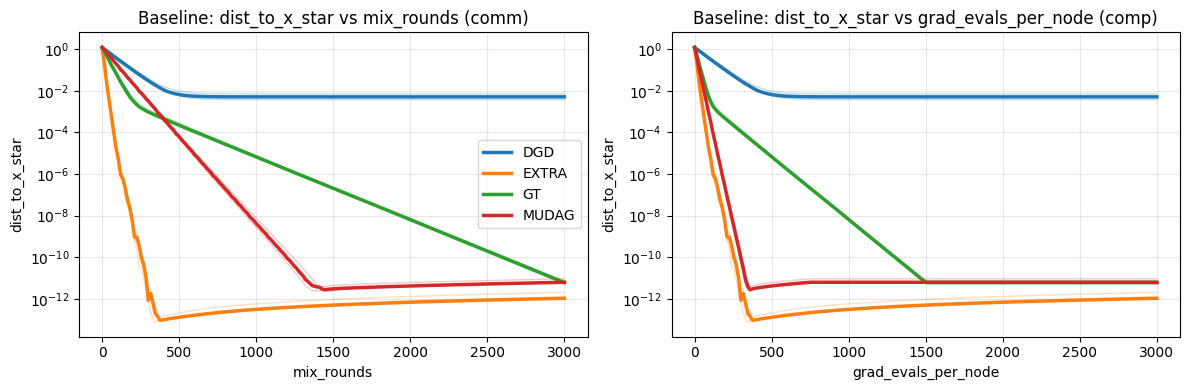

In [5]:
# 2) Baseline benchmark plot (median across 3 seeds), two x-axes

ALG_COLORS = {
    'DGD': 'C0',
    'EXTRA': 'C1',
    'GT': 'C2',
    'MUDAG': 'C3',
}

best_runs = {alg: baseline_runs[alg][best_hp[alg]] for alg in best_hp}

# Determine a common grad-evals grid based on the observed budgets.
grad_max = 0.0
for alg, by_seed in best_runs.items():
    for seed, res in by_seed.items():
        grad_max = max(grad_max, float(res.history[-1]['grad_evals_per_node']))

grad_grid = np.linspace(0.0, grad_max, 201)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax_comm, ax_comp = axes

for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
    color = ALG_COLORS[alg]
    med_y_comm, per_seed_comm = aggregate_seed_curves(
        best_runs[alg], x_key='mix_rounds', y_key='dist_to_x_star', grid=mix_grid, max_x=max_mix
    )
    for seed, y in per_seed_comm.items():
        ax_comm.plot(mix_grid, y, color=color, alpha=0.25, linewidth=1.0)
    ax_comm.plot(mix_grid, med_y_comm, color=color, linewidth=2.5, label=alg)

    med_y_comp, per_seed_comp = aggregate_seed_curves(
        best_runs[alg], x_key='grad_evals_per_node', y_key='dist_to_x_star', grid=grad_grid, max_x=grad_max
    )
    for seed, y in per_seed_comp.items():
        ax_comp.plot(grad_grid, y, color=color, alpha=0.25, linewidth=1.0)
    ax_comp.plot(grad_grid, med_y_comp, color=color, linewidth=2.5, label=alg)

ax_comm.set_title('Baseline: dist_to_x_star vs mix_rounds (comm)')
ax_comm.set_xlabel('mix_rounds')
ax_comm.set_ylabel('dist_to_x_star')
ax_comm.set_yscale('log')
ax_comm.grid(True, which='both', alpha=0.3)
ax_comm.legend()

ax_comp.set_title('Baseline: dist_to_x_star vs grad_evals_per_node (comp)')
ax_comp.set_xlabel('grad_evals_per_node')
ax_comp.set_ylabel('dist_to_x_star')
ax_comp.set_yscale('log')
ax_comp.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

Topology sweep summary (median over seeds):

[path]  gamma=0.01136  chi=57.7  lambda2_W=0.988642
  MUDAG tuned c_K=2.0
  DGD    med mix→tol=-       med grads→tol=-     
  EXTRA  med mix→tol=60.0    med grads→tol=60.0  
  GT     med mix→tol=2700    med grads→tol=1351  
  MUDAG  med mix→tol=1080    med grads→tol=90.0  

[cycle]  gamma=0.04466  chi=14.9  lambda2_W=0.955342
  MUDAG tuned c_K=1.0
  DGD    med mix→tol=-       med grads→tol=-     
  EXTRA  med mix→tol=60.0    med grads→tol=60.0  
  GT     med mix→tol=300.0   med grads→tol=151.0 
  MUDAG  med mix→tol=360.0   med grads→tol=90.0  

[er]  gamma=0.5  chi=1  lambda2_W=0.500000
  MUDAG tuned c_K=0.5
  DGD    med mix→tol=-       med grads→tol=-     
  EXTRA  med mix→tol=60.0    med grads→tol=60.0  
  GT     med mix→tol=240.0   med grads→tol=121.0 
  MUDAG  med mix→tol=180.0   med grads→tol=90.0  

[complete]  gamma=0.5  chi=1  lambda2_W=0.500000
  MUDAG tuned c_K=0.5
  DGD    med mix→tol=-       med grads→tol=-     
  EXTRA  med mix→

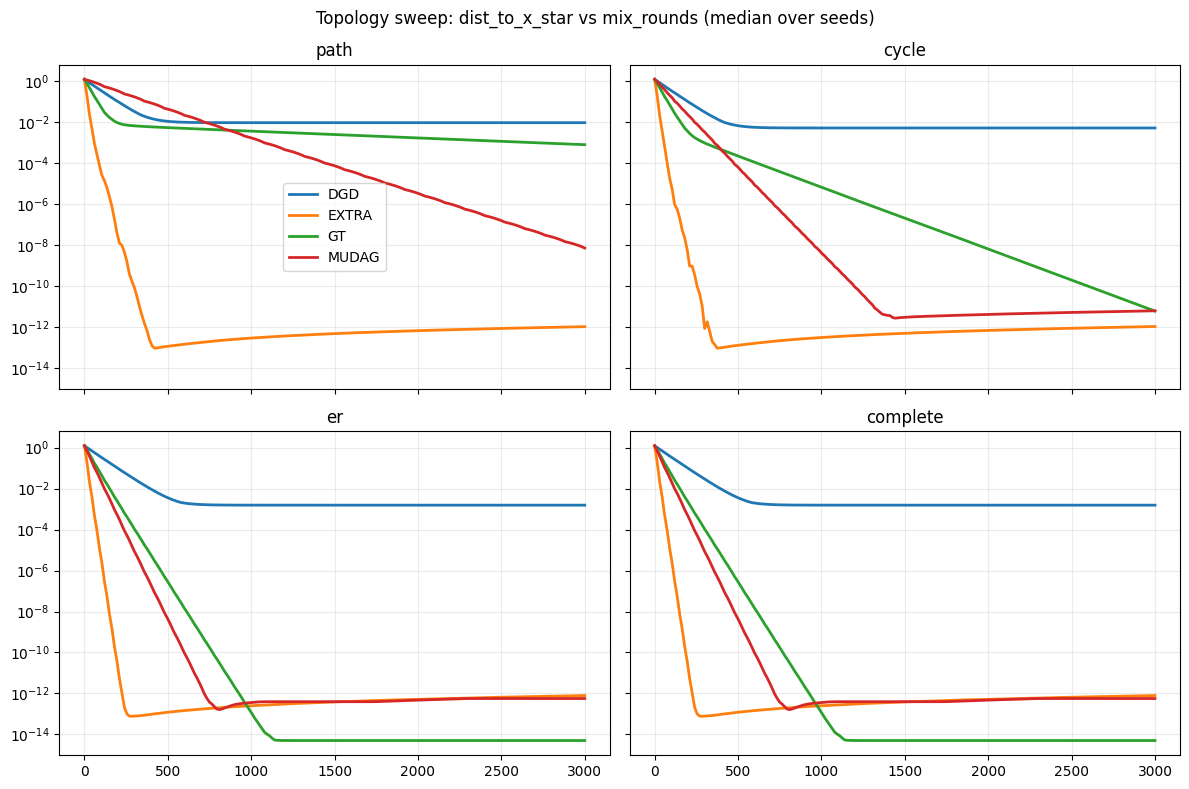

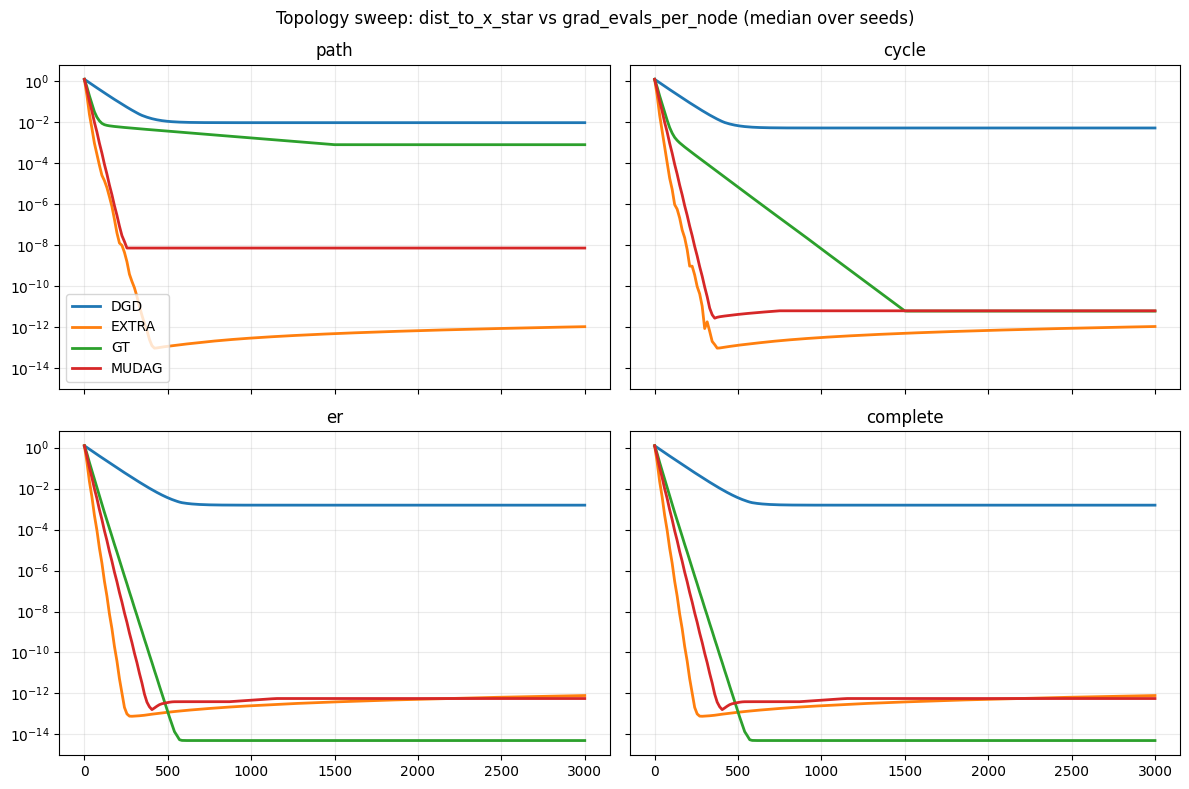

In [6]:
# 3) Topology sweep (fixed task family), benchmark on both axes

topologies = [
    ('path', {}),
    ('cycle', {}),
    ('er', {'er_p': 0.3}),
    ('complete', {}),
]

topo_runs: dict[str, dict[str, dict[int, object]]] = {g: {alg: {} for alg in best_hp} for g, _ in topologies}
topo_graph_stats = {}  # kind -> stats
topo_problem_stats = {}  # kind -> per-seed stats
topo_mudag_c_K = {}  # kind -> chosen c_K


def pick_best_mudag_c_K(runs_by_c_K: dict[float, dict[int, object]]) -> float:
    rows = []
    for c_K, res_by_seed in runs_by_c_K.items():
        mix_to = []
        grad_to = []
        final_dist = []
        for seed, res in res_by_seed.items():
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
            mix_to.append(np.inf if m is None else m)
            grad_to.append(np.inf if g is None else g)
            final_dist.append(float(res.history[-1]['dist_to_x_star']))
        rows.append({
            'c_K': float(c_K),
            'med_mix_to_tol': float(np.median(mix_to)),
            'med_grads_to_tol': float(np.median(grad_to)),
            'med_final_dist': float(np.median(final_dist)),
        })

    rows.sort(key=lambda r: (r['med_mix_to_tol'], r['med_grads_to_tol'], r['med_final_dist'], r['c_K']))

    finite = [r for r in rows if np.isfinite(float(r['med_mix_to_tol']))]
    if finite:
        return float(finite[0]['c_K'])

    # If nothing reaches tol_dist, fall back to smallest final distance.
    return float(min(rows, key=lambda r: float(r['med_final_dist']))['c_K'])


for kind, gkw in topologies:
    topo_problem_stats[kind] = {}

    # We tune c_K per-topology; reusing the baseline-tuned c_K can diverge (e.g. on a path).
    mudag_runs_by_c_K: dict[float, dict[int, object]] = {float(c): {} for c in c_K_grid}

    for seed in seeds:
        graph = build_graph(kind, n, seed=seed, lazy=lazy, **gkw)
        problem = build_problem(baseline_problem_family, graph, seed=seed, d=d, **baseline_problem_kwargs)

        if kind not in topo_graph_stats:
            topo_graph_stats[kind] = graph.ensure_stats()

        topo_problem_stats[kind][int(seed)] = problem.ensure_stats()

        rng = np.random.default_rng(seed)
        X0 = _consensus_init(rng.normal(size=(n, d)))

        # alpha-based algorithms use their chosen factor, rescaled by each problem's L_l
        for alg in ['DGD', 'EXTRA', 'GT']:
            factor = float(best_hp[alg])
            alpha = alpha_from_factor(problem, factor)
            make_alg = ALG_SPECS[alg]
            topo_runs[kind][alg][int(seed)] = run_experiment(
                problem, make_alg(alpha), stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every
            )

        # MUDAG: run a small c_K grid and keep the best (median over seeds)
        for c_K in c_K_grid:
            mudag_runs_by_c_K[float(c_K)][int(seed)] = run_experiment(
                problem, MUDAG(c_K=float(c_K)), stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every
            )

    chosen_c_K = pick_best_mudag_c_K(mudag_runs_by_c_K)
    topo_mudag_c_K[kind] = chosen_c_K
    for seed in seeds:
        topo_runs[kind]['MUDAG'][int(seed)] = mudag_runs_by_c_K[chosen_c_K][int(seed)]

# Summary table: median budgets to reach tol_dist
print('Topology sweep summary (median over seeds):')
for kind, _ in topologies:
    gs = topo_graph_stats[kind]
    print()
    print(f"[{kind}]  gamma={gs.gamma:.4g}  chi={gs.chi:.3g}  lambda2_W={gs.lambda2_W:.6f}")
    print(f"  MUDAG tuned c_K={topo_mudag_c_K[kind]}")
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        mix_to = []
        grad_to = []
        for seed, res in topo_runs[kind][alg].items():
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
            mix_to.append(np.inf if m is None else m)
            grad_to.append(np.inf if g is None else g)
        med_m = float(np.median(mix_to))
        med_g = float(np.median(grad_to))
        print(
            f"  {alg:<5}  med mix→tol={_fmt_budget(None if not np.isfinite(med_m) else med_m):<6}  med grads→tol={_fmt_budget(None if not np.isfinite(med_g) else med_g):<6}"
        )

# Plot: 2x2 subplots by topology (median curves), both axes

# Compute a common comp-grid max across all topo runs.
grad_max_topo = 0.0
for kind, _ in topologies:
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        for seed, res in topo_runs[kind][alg].items():
            grad_max_topo = max(grad_max_topo, float(res.history[-1]['grad_evals_per_node']))
grad_grid_topo = np.linspace(0.0, grad_max_topo, 201)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, (kind, _) in zip(axes, topologies):
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        med_y, _ = aggregate_seed_curves(
            topo_runs[kind][alg], x_key='mix_rounds', y_key='dist_to_x_star', grid=mix_grid, max_x=max_mix
        )
        ax.plot(mix_grid, med_y, color=ALG_COLORS[alg], linewidth=2.0, label=alg)
    ax.set_title(kind)
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.25)

axes[0].legend()
fig.suptitle('Topology sweep: dist_to_x_star vs mix_rounds (median over seeds)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, (kind, _) in zip(axes, topologies):
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        med_y, _ = aggregate_seed_curves(
            topo_runs[kind][alg],
            x_key='grad_evals_per_node',
            y_key='dist_to_x_star',
            grid=grad_grid_topo,
            max_x=grad_max_topo,
        )
        ax.plot(grad_grid_topo, med_y, color=ALG_COLORS[alg], linewidth=2.0, label=alg)
    ax.set_title(kind)
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.25)

axes[0].legend()
fig.suptitle('Topology sweep: dist_to_x_star vs grad_evals_per_node (median over seeds)')
plt.tight_layout()
plt.show()

Conditioning sweep summary (median over seeds):

[kappa≈10]
  MUDAG tuned c_K=0.5
  DGD    med mix→tol=2510    med grads→tol=2510  
  EXTRA  med mix→tol=230.0   med grads→tol=230.0 
  GT     med mix→tol=940.0   med grads→tol=471.0 
  MUDAG  med mix→tol=1820    med grads→tol=260.0 

[kappa≈100]
  MUDAG tuned c_K=0.5
  DGD    med mix→tol=-       med grads→tol=-     
  EXTRA  med mix→tol=-       med grads→tol=-     
  GT     med mix→tol=-       med grads→tol=-     
  MUDAG  med mix→tol=-       med grads→tol=-     


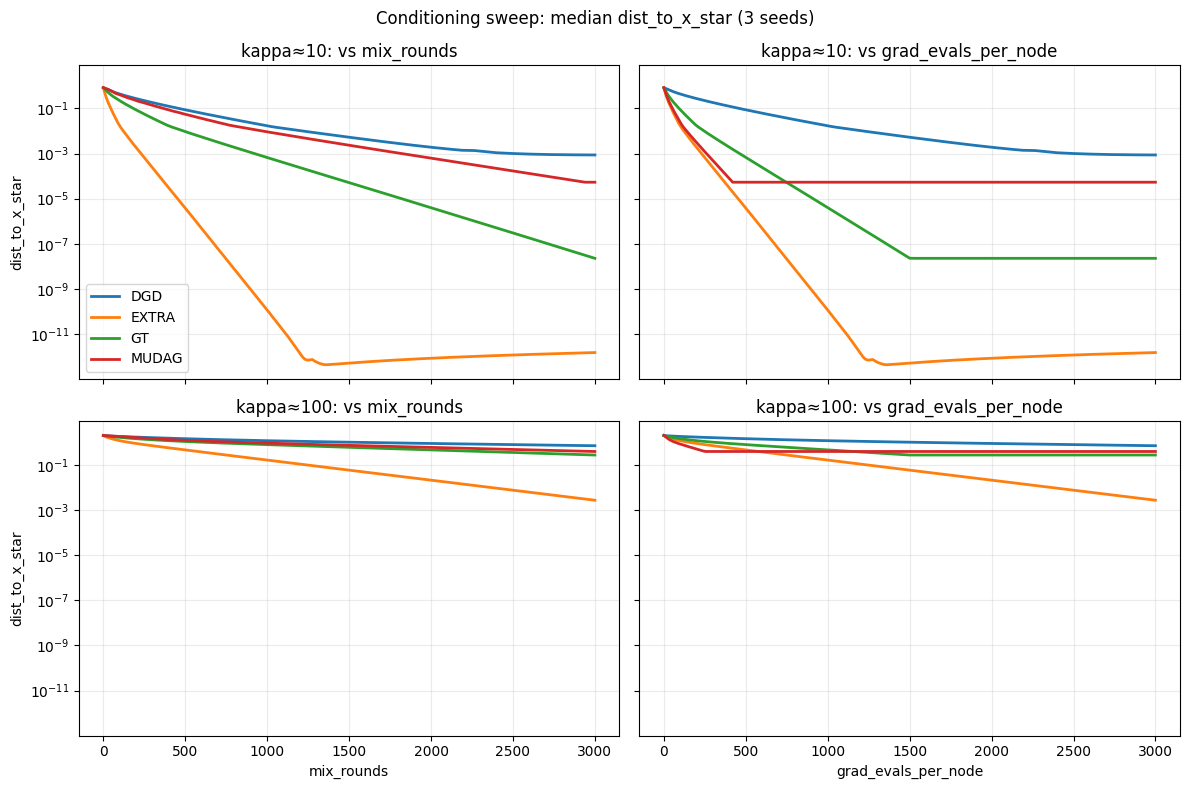

In [7]:
# 4) Conditioning sweep (fixed graph), benchmark on both axes

cond_cases = [
    ('kappa≈10', dict(mu=1.0, L=10.0)),
    ('kappa≈100', dict(mu=0.1, L=10.0)),
]

cond_runs: dict[str, dict[str, dict[int, object]]] = {name: {alg: {} for alg in best_hp} for name, _ in cond_cases}
cond_stats = {}
cond_mudag_c_K = {}  # name -> chosen c_K


def pick_best_mudag_c_K(runs_by_c_K: dict[float, dict[int, object]]) -> float:
    rows = []
    for c_K, res_by_seed in runs_by_c_K.items():
        mix_to = []
        grad_to = []
        final_dist = []
        for seed, res in res_by_seed.items():
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
            mix_to.append(np.inf if m is None else m)
            grad_to.append(np.inf if g is None else g)
            final_dist.append(float(res.history[-1]['dist_to_x_star']))
        rows.append({
            'c_K': float(c_K),
            'med_mix_to_tol': float(np.median(mix_to)),
            'med_grads_to_tol': float(np.median(grad_to)),
            'med_final_dist': float(np.median(final_dist)),
        })

    rows.sort(key=lambda r: (r['med_mix_to_tol'], r['med_grads_to_tol'], r['med_final_dist'], r['c_K']))

    finite = [r for r in rows if np.isfinite(float(r['med_mix_to_tol']))]
    if finite:
        return float(finite[0]['c_K'])

    # If nothing reaches tol_dist, fall back to smallest final distance.
    return float(min(rows, key=lambda r: float(r['med_final_dist']))['c_K'])


for name, pkw in cond_cases:
    mudag_runs_by_c_K: dict[float, dict[int, object]] = {float(c): {} for c in c_K_grid}

    for seed in seeds:
        graph = build_graph('cycle', n, seed=seed, lazy=lazy)
        problem = build_problem('shared_eigenbasis', graph, seed=seed, d=d, **pkw)
        cond_stats.setdefault(name, {})[int(seed)] = problem.ensure_stats()

        rng = np.random.default_rng(seed)
        X0 = _consensus_init(rng.normal(size=(n, d)))

        for alg in ['DGD', 'EXTRA', 'GT']:
            factor = float(best_hp[alg])
            alpha = alpha_from_factor(problem, factor)
            cond_runs[name][alg][int(seed)] = run_experiment(
                problem, ALG_SPECS[alg](alpha), stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every
            )

        # MUDAG: tune c_K for this conditioning regime.
        for c_K in c_K_grid:
            mudag_runs_by_c_K[float(c_K)][int(seed)] = run_experiment(
                problem, MUDAG(c_K=float(c_K)), stop=[MaxMixRounds(max_mix)], X0=X0, log_every=log_every
            )

    chosen_c_K = pick_best_mudag_c_K(mudag_runs_by_c_K)
    cond_mudag_c_K[name] = chosen_c_K
    for seed in seeds:
        cond_runs[name]['MUDAG'][int(seed)] = mudag_runs_by_c_K[chosen_c_K][int(seed)]

print('Conditioning sweep summary (median over seeds):')
for name, _ in cond_cases:
    print()
    print(f"[{name}]")
    print(f"  MUDAG tuned c_K={cond_mudag_c_K[name]}")
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        mix_to = []
        grad_to = []
        for seed, res in cond_runs[name][alg].items():
            m = first_budget_to_tol(res, x_key='mix_rounds', y_key='dist_to_x_star', tol=tol_dist)
            g = first_budget_to_tol(res, x_key='grad_evals_per_node', y_key='dist_to_x_star', tol=tol_dist)
            mix_to.append(np.inf if m is None else m)
            grad_to.append(np.inf if g is None else g)
        med_m = float(np.median(mix_to))
        med_g = float(np.median(grad_to))
        print(
            f"  {alg:<5}  med mix→tol={_fmt_budget(None if not np.isfinite(med_m) else med_m):<6}  med grads→tol={_fmt_budget(None if not np.isfinite(med_g) else med_g):<6}"
        )

# Common comp-grid for conditioning plots
grad_max_cond = 0.0
for name, _ in cond_cases:
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        for seed, res in cond_runs[name][alg].items():
            grad_max_cond = max(grad_max_cond, float(res.history[-1]['grad_evals_per_node']))
grad_grid_cond = np.linspace(0.0, grad_max_cond, 201)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey=True)
for row, (name, _) in enumerate(cond_cases):
    ax_comm = axes[row, 0]
    ax_comp = axes[row, 1]
    for alg in ['DGD', 'EXTRA', 'GT', 'MUDAG']:
        med_y_comm, _ = aggregate_seed_curves(
            cond_runs[name][alg], x_key='mix_rounds', y_key='dist_to_x_star', grid=mix_grid, max_x=max_mix
        )
        ax_comm.plot(mix_grid, med_y_comm, color=ALG_COLORS[alg], linewidth=2.0, label=alg)

        med_y_comp, _ = aggregate_seed_curves(
            cond_runs[name][alg], x_key='grad_evals_per_node', y_key='dist_to_x_star', grid=grad_grid_cond, max_x=grad_max_cond
        )
        ax_comp.plot(grad_grid_cond, med_y_comp, color=ALG_COLORS[alg], linewidth=2.0, label=alg)

    ax_comm.set_title(f'{name}: vs mix_rounds')
    ax_comm.set_yscale('log')
    ax_comm.grid(True, which='both', alpha=0.25)
    ax_comp.set_title(f'{name}: vs grad_evals_per_node')
    ax_comp.set_yscale('log')
    ax_comp.grid(True, which='both', alpha=0.25)

axes[0, 0].legend()
axes[1, 0].set_xlabel('mix_rounds')
axes[1, 1].set_xlabel('grad_evals_per_node')
axes[0, 0].set_ylabel('dist_to_x_star')
axes[1, 0].set_ylabel('dist_to_x_star')

fig.suptitle('Conditioning sweep: median dist_to_x_star (3 seeds)')
plt.tight_layout()
plt.show()

## Notes (interpretation + gotchas)

- **MUDAG is sensitive to `c_K`.** Too-small values can diverge on slow-mixing graphs (large $\chi$, e.g. a path). This notebook therefore **tunes `c_K` per topology / per conditioning case** using a small `c_K_grid`.
- **`c_K` controls a comm–comp tradeoff.** Larger `c_K` means a longer inner mixing polynomial (more `mix_rounds` per outer step), which can improve progress per gradient evaluation but costs more communication.
- **DGD with a fixed step size typically converges to a neighborhood** (so it may not reach `tol_dist`). Methods like EXTRA / Gradient Tracking are expected to reach high accuracy on these strongly convex quadratics.
- If a case (e.g. $\kappa\approx 100$) does not reach `tol_dist` within `max_mix`, treat it as **budget-limited** rather than a correctness issue; increase `max_mix` or relax `tol_dist` to get a more informative comparison.
- Notebook implementation note: `pick_best_mudag_c_K` is defined twice (topology + conditioning sweeps). It can be moved into the helpers cell if you prefer less duplication.

## Takeaways (expected qualitative checks)

- Comparisons are meaningful on `mix_rounds` (communication) and `grad_evals_per_node` (computation); `t` is not comparable across methods.
- Worse conditioning (larger $\kappa$) slows convergence across all methods.
- Harder topologies (smaller $\gamma$ / larger $\chi$) require more communication to reach the same accuracy.
- MUDAG trades extra mixing per outer step for acceleration; the comm-vs-comp plots make this tradeoff explicit.